# Harder synthetic-100 regression benchmark

This notebook makes the original synthetic regression problem harder without
changing its underlying linear interpretation. It retains 500 samples, 100
features, 10 directly informative features, 10 redundant signal proxies, and
80 noise features, but increases target noise from 20 to 60 and redundant-proxy
noise from 10% to 30% of each proxy's standard deviation.

Linear, RBF, and polynomial MiSTIC models are evaluated with
`rank_weight=0.75`, 20 members, ten seeded inner shuffle-split constructions,
forward-knee selection, `addition_factor=0.1`, `max_features=20`, separate
features and parameters, no per-step tuning, and final knee retuning. All fits
share one fixed untouched blind set.

References include sklearn RBF-SVR on all 100 features, linear-SVR RFE to 20,
kernel-matched sklearn SVR on each MiSTIC ensemble's knee-ranked unified
features, and an RBF-SVR oracle on the known 20-feature signal set.


In [1]:
import time
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.datasets import make_regression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, ShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents]
                 if (path / "mistic" / "svmSet.py").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svr, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)


Matplotlib is building the font cache; this may take a moment.


In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))
DATA_SEED = 2026
BLIND_SET_SEED = 42
INNER_SEEDS = list(range(10))
MEMBER_COUNTS = [20]
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
RANK_WEIGHT = 0.75
MAX_FEATURES = 20
ADDITION_FACTOR = 0.1
RFE_FEATURE_COUNT = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]
EPSILON_VALUES = [0.05, 0.1, 0.2]
POLY_DEGREES = [2, 3]

# Start with 10 informative plus 80 independent noise predictors. Insert 10
# noisy linear combinations of the informative block as redundant signal.
base_X, y_values, coefficients = make_regression(
    n_samples=N_SAMPLES, n_features=90, n_informative=N_INFORMATIVE,
    noise=60.0, shuffle=False, random_state=DATA_SEED, coef=True,
)
rng = np.random.default_rng(DATA_SEED)
mixing = rng.normal(size=(N_INFORMATIVE, N_REDUNDANT))
redundant = base_X[:, :N_INFORMATIVE] @ mixing
redundant += rng.normal(scale=0.30 * redundant.std(axis=0), size=redundant.shape)
X_values = np.column_stack([base_X[:, :N_INFORMATIVE], redundant, base_X[:, N_INFORMATIVE:]])
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="target")

X_train, X_blind, y_train_raw, y_blind_raw = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=BLIND_SET_SEED,
)
y_mean = y_train_raw.mean()
y_scale = y_train_raw.std(ddof=0)
y_train = (y_train_raw - y_mean) / y_scale
y_blind = (y_blind_raw - y_mean) / y_scale
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")
print(f"Training target mean={y_train.mean():.3g}, SD={y_train.std(ddof=0):.3g}")


Training rows: 375; fixed blind rows: 125
Training target mean=1.42e-17, SD=1


In [3]:
def metric_row(y_true, predictions):
    r = pearsonr(y_true, predictions).statistic
    return {
        "r2": r2_score(y_true, predictions),
        "rmse": root_mean_squared_error(y_true, predictions),
        "mae": mean_absolute_error(y_true, predictions),
        "pearson_r2": r * r,
    }


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), signal_count / len(features)


def sklearn_grid(seed):
    return GridSearchCV(
        Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel="rbf"))]),
        {"svr__C": C_VALUES, "svr__gamma": GAMMA_VALUES,
         "svr__epsilon": EPSILON_VALUES},
        scoring="r2", cv=KFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1, refit=True,
    )


def fit_sklearn(features, seed):
    features = np.asarray(features, dtype=int)
    return sklearn_grid(seed).fit(X_train.iloc[:, features], y_train)


def fit_mistic(seed, num_models, kernel_type):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(X_scaled, np.asarray(y_train), num_feature_medoids=20,
                   ensemble_validation_size=0.0)
    splitter = ShuffleSplit(n_splits=num_models,
                            test_size=INNER_VALIDATION_SIZE,
                            random_state=seed)
    generated = list(splitter.split(X_scaled, y_train))
    splits.train = [train for train, _ in generated]
    splits.test = [test for _, test in generated]
    splits.type = "regression_shuffle_split"
    ensemble = svmSet(
        SVR(kernel="precomputed"), splits,
        score_method=score_svr(weight=0.0).score,
        kernel=kernelWrapper(type=kernel_type),
        separate_feature_sets=True, separate_parameters=True,
    )
    if kernel_type == "linear":
        grid = [
            paramSet(model={"C": c, "epsilon": epsilon}, kernel={})
            for c in C_VALUES for epsilon in EPSILON_VALUES
        ]
    elif kernel_type == "rbf":
        grid = [
            paramSet(model={"C": c, "epsilon": epsilon},
                     kernel={"gamma": gamma})
            for c in C_VALUES for gamma in GAMMA_VALUES
            for epsilon in EPSILON_VALUES
        ]
    elif kernel_type == "polynomial":
        grid = [
            paramSet(model={"C": c, "epsilon": epsilon},
                     kernel={"gamma": gamma, "degree": degree, "coef0": 1.0})
            for c in C_VALUES for gamma in GAMMA_VALUES
            for epsilon in EPSILON_VALUES for degree in POLY_DEGREES
        ]
    else:
        raise ValueError(kernel_type)
    ensemble.greedy_forward_selection(
        addition_factor=ADDITION_FACTOR, max_features=MAX_FEATURES,
        parameter_grid=grid,
        feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
        set_for_rank="sample", tune_models_each_step=False,
        post_find_knee=True,
    )
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([f for f in ensemble.unified_sorted_features if f in unified], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def sklearn_row(method, features, seed, associated_members=0):
    features = np.asarray(features, dtype=int)
    model = fit_sklearn(features, seed)
    predictions = model.predict(X_blind.iloc[:, features])
    recall, precision = recovery(features)
    return {
        "seed": seed, "method": method, "num_models": 1,
        "associated_mistic_members": associated_members,
        "knee_feature_count": np.nan, "mean_member_features": np.nan,
        "num_unified_features": len(features),
        "top20_signal_recall": recall, "top20_signal_precision": precision,
        "member_disagreement": 0.0, "cv_best_score": model.best_score_,
        **metric_row(y_blind, predictions),
    }


## Run the harder paired benchmark

The generic sklearn references are fitted once per seed. Each kernel-specific
unified reference uses features generated by the matching MiSTIC ensemble and
is tuned with that same kernel family.


In [4]:
rows = []
NUM_MODELS = 20
KERNEL_TYPES = ["linear", "rbf", "polynomial"]
all_features = np.arange(N_FEATURES)
oracle_features = np.arange(N_INFORMATIVE + N_REDUNDANT)

selector_scaler = StandardScaler().fit(X_train)
rfe = RFE(
    estimator=SVR(kernel="linear", C=1.0, epsilon=0.1),
    n_features_to_select=RFE_FEATURE_COUNT, step=0.1,
).fit(selector_scaler.transform(X_train), y_train)
rfe_features = np.flatnonzero(rfe.support_)

for seed in INNER_SEEDS:
    rows.append(sklearn_row("sklearn SVR: all 100 features", all_features, seed))
    rows.append(sklearn_row("sklearn SVR: linear-SVR RFE (20)", rfe_features, seed))
    rows.append(sklearn_row("sklearn SVR oracle: known signal (20)", oracle_features, seed))

for kernel_type in KERNEL_TYPES:
    for seed in INNER_SEEDS:
        started = time.perf_counter()
        scaler, ensemble, knee_count = fit_mistic(seed, NUM_MODELS, kernel_type)
        X_blind_scaled = scaler.transform(X_blind)
        predictions = ensemble.predict(X_blind_scaled)
        top20 = ranked_unified_features(ensemble, 20)
        unified_features = ranked_unified_features(ensemble, knee_count)
        recall, precision = recovery(top20)
        selected_counts = np.asarray([len(f) for f in ensemble.features])
        member_predictions = np.column_stack([
            ensemble.predict(X_blind_scaled, model_index=i)
            for i in range(NUM_MODELS)
        ])
        residuals = np.asarray(y_blind)[:, None] - member_predictions
        residual_correlations = [
            abs(np.corrcoef(residuals[:, i], residuals[:, j])[0, 1])
            for i in range(NUM_MODELS) for j in range(i + 1, NUM_MODELS)
        ]
        rows.append({
            "seed": seed,
            "method": f"MiSTIC {kernel_type}, weight=0.75 (20 members)",
            "kernel": kernel_type, "num_models": NUM_MODELS,
            "associated_mistic_members": NUM_MODELS,
            "knee_feature_count": knee_count,
            "mean_member_features": selected_counts.mean(),
            "num_unified_features": len(ensemble.unified_features),
            "top20_signal_recall": recall,
            "top20_signal_precision": precision,
            "member_disagreement": 1 - np.mean(residual_correlations),
            "cv_best_score": np.nan,
            "elapsed_seconds": time.perf_counter() - started,
            **metric_row(y_blind, predictions),
        })

        # Kernel-matched sklearn reference on the knee-ranked unified subset.
        if kernel_type == "linear":
            reference = GridSearchCV(
                Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel="linear"))]),
                {"svr__C": C_VALUES, "svr__epsilon": EPSILON_VALUES},
                scoring="r2", cv=KFold(4, shuffle=True, random_state=seed),
                n_jobs=-1, refit=True,
            ).fit(X_train.iloc[:, unified_features], y_train)
        elif kernel_type == "rbf":
            reference = fit_sklearn(unified_features, seed)
        else:
            reference = GridSearchCV(
                Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel="poly", coef0=1.0))]),
                {"svr__C": C_VALUES, "svr__gamma": GAMMA_VALUES,
                 "svr__epsilon": EPSILON_VALUES, "svr__degree": POLY_DEGREES},
                scoring="r2", cv=KFold(4, shuffle=True, random_state=seed),
                n_jobs=-1, refit=True,
            ).fit(X_train.iloc[:, unified_features], y_train)
        ref_predictions = reference.predict(X_blind.iloc[:, unified_features])
        ref_recall, ref_precision = recovery(unified_features)
        rows.append({
            "seed": seed,
            "method": f"sklearn {kernel_type}: knee-ranked unified",
            "kernel": kernel_type, "num_models": 1,
            "associated_mistic_members": NUM_MODELS,
            "knee_feature_count": knee_count,
            "mean_member_features": np.nan,
            "num_unified_features": len(unified_features),
            "top20_signal_recall": ref_recall,
            "top20_signal_precision": ref_precision,
            "member_disagreement": 0.0,
            "cv_best_score": reference.best_score_,
            "elapsed_seconds": np.nan,
            **metric_row(y_blind, ref_predictions),
        })
        print(f"kernel={kernel_type}, seed={seed}, knee={knee_count}, "
              f"elapsed={rows[-2]['elapsed_seconds']:.1f}s")

results = pd.DataFrame(rows)
results_path = repo_root / "validation/Synthetic100_regression_harder_kernel_comparison_10seeds_results.csv"
results.to_csv(results_path, index=False)
results


Number of Features: 1, Score: 0.075


Number of Features: 10, Score: 0.658


Number of Features: 19, Score: 0.808


Number of Features: 20, Score: 0.809


Number of Features: 100, Score: 0.784


...

Number of Features: 10, Score: 0.347


Number of Features: 19, Score: 0.503


Number of Features: 20, Score: 0.497
Number of Features: 100, Score: 0.321


kernel=polynomial, seed=9, knee=19, elapsed=67.5s


,seed,method,num_models,associated_mistic_members,knee_feature_count,mean_member_features,num_unified_features,top20_signal_recall,top20_signal_precision,member_disagreement,cv_best_score,r2,rmse,mae,pearson_r2,kernel,elapsed_seconds
0,0,sklearn SVR: all 100 features,1,0,NaN,NaN,100,1.00,0.200000,0.000000,0.805737,0.735064,0.439908,0.354142,0.735395,NaN,NaN
1,0,sklearn SVR: linear-SVR RFE (20),1,0,NaN,NaN,20,0.65,0.650000,0.000000,0.861827,0.787302,0.394160,0.315958,0.789842,NaN,NaN
2,0,sklearn SVR oracle: known signal (20),1,0,NaN,NaN,20,1.00,1.000000,0.000000,0.848627,0.798579,0.383568,0.302914,0.798993,NaN,NaN
3,1,sklearn SVR: all 100 features,1,0,NaN,NaN,100,1.00,0.200000,0.000000,0.799353,0.735064,0.439908,0.354142,0.735395,NaN,NaN
4,1,sklearn SVR: linear-SVR RFE (20),1,0,NaN,NaN,20,0.65,0.650000,0.000000,0.859586,0.787302,0.394160,0.315958,0.789842,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,7,sklearn polynomial: knee-ranked unified,1,20,19.0,NaN,19,0.60,0.631579,0.000000,0.851630,0.785364,0.395951,0.309320,0.789109,polynomial,NaN
86,8,"MiSTIC polynomial, weight=0.75 (20 members)",20,20,19.0,19.0,74,0.60,0.600000,0.254815,NaN,0.768897,0.410860,0.325139,0.770482,polynomial,65.745294
87,8,sklearn polynomial: knee-ranked unified,1,20,19.0,NaN,19,0.60,0.631579,0.000000,0.838407,0.775678,0.404787,0.311444,0.777216,polynomial,NaN
88,9,"MiSTIC polynomial, weight=0.75 (20 members)",20,20,19.0,19.0,71,0.60,0.600000,0.202363,NaN,0.750533,0.426872,0.335988,0.752806,polynomial,67.521823


In [5]:
metrics = ["r2", "rmse", "mae", "pearson_r2", "knee_feature_count",
           "mean_member_features", "num_unified_features", "top20_signal_recall",
           "top20_signal_precision", "member_disagreement"]
summary = results.groupby("method")[metrics].agg(["mean", "std"])
summary.round(4)


r2            rmse          \
                                               mean     std    mean     std   
method                                                                        
MiSTIC linear, weight=0.75 (20 members)      0.7831  0.0091  0.3980  0.0083   
MiSTIC polynomial, weight=0.75 (20 members)  0.7638  0.0072  0.4153  0.0063   
MiSTIC rbf, weight=0.75 (20 members)         0.7439  0.0479  0.4309  0.0399   
sklearn SVR oracle: known signal (20)        0.7960  0.0027  0.3860  0.0025   
sklearn SVR: all 100 features                0.7351  0.0000  0.4399  0.0000   
sklearn SVR: linear-SVR RFE (20)             0.7872  0.0006  0.3942  0.0005   
sklearn linear: knee-ranked unified          0.8084  0.0064  0.3740  0.0062   
sklearn polynomial: knee-ranked unified      0.7770  0.0058  0.4035  0.0053   
sklearn rbf: knee-ranked unified             0.7471  0.0650  0.4268  0.0541   

                                                mae         pearson_r2  \
                                               mean     std       mean   
method                                                                   
MiSTIC linear, weight=0.75 (20 members)      0.3132  0.0048     0.7837   
MiSTIC polynomial, weight=0.75 (20 members)  0.3285  0.0053     0.7656   
MiSTIC rbf, weight=0.75 (20 members)         0.3450  0.0342     0.7458   
sklearn SVR oracle: known signal (20)        0.3036  0.0007     0.7970   
sklearn SVR: all 100 features                0.3541  0.0000     0.7354   
sklearn SVR: linear-SVR RFE (20)             0.3144  0.0022     0.7901   
sklearn linear: knee-ranked unified          0.2993  0.0062     0.8124   
sklearn polynomial: knee-ranked unified      0.3098  0.0034     0.7802   
sklearn rbf: knee-ranked unified             0.3389  0.0425     0.7497   

                                                    knee_feature_count  \
                                                std               mean   
method                                                                   
MiSTIC linear, weight=0.75 (20 members)      0.0092               19.2   
MiSTIC polynomial, weight=0.75 (20 members)  0.0067               19.1   
MiSTIC rbf, weight=0.75 (20 members)         0.0467               15.4   
sklearn SVR oracle: known signal (20)        0.0023                NaN   
sklearn SVR: all 100 features                0.0000                NaN   
sklearn SVR: linear-SVR RFE (20)             0.0002                NaN   
sklearn linear: knee-ranked unified          0.0058               19.2   
sklearn polynomial: knee-ranked unified      0.0055               19.1   
sklearn rbf: knee-ranked unified             0.0621               15.4   

                                                    mean_member_features  \
                                                std                 mean   
method                                                                     
MiSTIC linear, weight=0.75 (20 members)      0.4216                 19.2   
MiSTIC polynomial, weight=0.75 (20 members)  0.3162                 19.1   
MiSTIC rbf, weight=0.75 (20 members)         4.6476                 15.4   
sklearn SVR oracle: known signal (20)           NaN                  NaN   
sklearn SVR: all 100 features                   NaN                  NaN   
sklearn SVR: linear-SVR RFE (20)                NaN                  NaN   
sklearn linear: knee-ranked unified          0.4216                  NaN   
sklearn polynomial: knee-ranked unified      0.3162                  NaN   
sklearn rbf: knee-ranked unified             4.6476                  NaN   

                                                    num_unified_features  \
                                                std                 mean   
method                                                                     
MiSTIC linear, weight=0.75 (20 members)      0.4216                 70.3   
MiSTIC polynomial, weight=0.75 (20 members)  0.3162                 66.8   
MiSTIC rbf, weight=0.75 (20 m

In [6]:
mistic = results[results["method"].str.startswith("MiSTIC")]
best_method = mistic.groupby("method")["r2"].mean().idxmax()
baseline = mistic.query("method == @best_method").set_index("seed")
paired_rows = []
for method, frame in results.groupby("method"):
    if method == best_method:
        continue
    other = frame.set_index("seed")
    for metric in ["r2", "rmse", "mae"]:
        advantage = baseline[metric] - other[metric]
        if metric in ["rmse", "mae"]:
            advantage = -advantage
        paired_rows.append({
            "best_mistic": best_method, "compared_with": method,
            "metric": metric, "mean_advantage": advantage.mean(),
            "std_difference": advantage.std(ddof=1),
            "best_wins": int((advantage > 0).sum()),
            "ties": int((advantage == 0).sum()),
            "best_losses": int((advantage < 0).sum()),
        })
paired = pd.DataFrame(paired_rows)
print(best_method)
paired.round(4)


MiSTIC linear, weight=0.75 (20 members)


,best_mistic,compared_with,metric,mean_advantage,std_difference,best_wins,ties,best_losses
0,"MiSTIC linear, weight=0.75 (20 members)","MiSTIC polynomial, weight=0.75 (20 members)",r2,0.0193,0.0104,10,0,0
1,"MiSTIC linear, weight=0.75 (20 members)","MiSTIC polynomial, weight=0.75 (20 members)",rmse,0.0174,0.0094,10,0,0
2,"MiSTIC linear, weight=0.75 (20 members)","MiSTIC polynomial, weight=0.75 (20 members)",mae,0.0154,0.0068,10,0,0
3,"MiSTIC linear, weight=0.75 (20 members)","MiSTIC rbf, weight=0.75 (20 members)",r2,0.0392,0.0452,9,0,1
4,"MiSTIC linear, weight=0.75 (20 members)","MiSTIC rbf, weight=0.75 (20 members)",rmse,0.0329,0.0374,9,0,1
5,"MiSTIC linear, weight=0.75 (20 members)","MiSTIC rbf, weight=0.75 (20 members)",mae,0.0319,0.0328,10,0,0
6,"MiSTIC linear, weight=0.75 (20 members)",sklearn SVR oracle: known signal (20),r2,-0.0130,0.0094,0,0,10
7,"MiSTIC linear, weight=0.75 (20 members)",sklearn SVR oracle: known signal (20),rmse,-0.0120,0.0086,0,0,10
8,"MiSTIC linear, weight=0.75 (20 members)",sklearn SVR oracle: known signal (20),mae,-0.0096,0.0047,0,0,10
9,"MiSTIC linear, weight=0.75 (20 members)",sklearn SVR: all 100 features,r2,0.0480,0.0091,10,0,0


/var/folders/q_/4g9fzlq94y3d38pwjs5rt9f40000gn/T/ipykernel_84521/3085182206.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=results, y="method", x="r2", order=order,


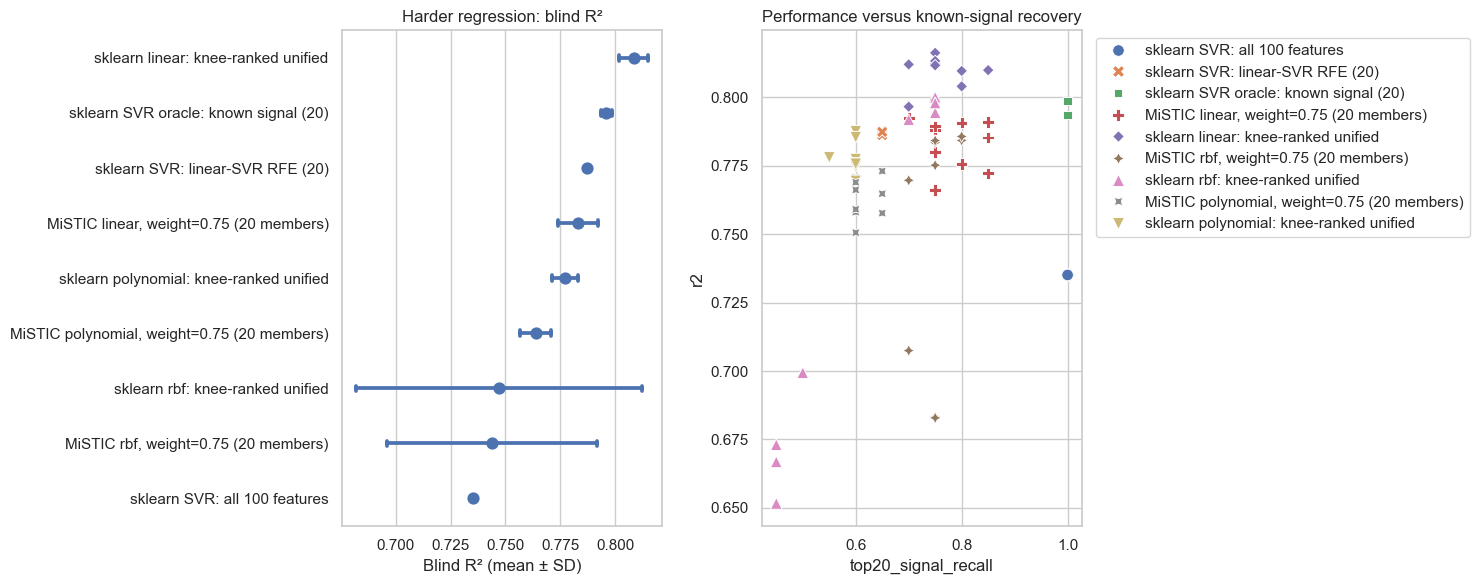

In [7]:
order = results.groupby("method")["r2"].mean().sort_values(ascending=False).index
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.pointplot(data=results, y="method", x="r2", order=order,
              errorbar="sd", join=False, capsize=0.10, ax=axes[0])
axes[0].set_title("Harder regression: blind R²")
axes[0].set_xlabel("Blind R² (mean ± SD)")
axes[0].set_ylabel("")
sns.scatterplot(data=results, x="top20_signal_recall", y="r2",
                hue="method", style="method", s=70, ax=axes[1])
axes[1].set_title("Performance versus known-signal recovery")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plot_path = repo_root / "validation/Synthetic100_regression_harder_kernel_comparison_10seeds.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()


## Interpretation notes

All ten runs share one fixed blind set. Seed variation measures sensitivity to
inner splitting and feature selection, not uncertainty over independent test
sets. The oracle uses known signal identities and is not a deployable model
selection procedure.
